# Final Assignment - Part 1

### Assignment Instructions

#### Part 1   |   Standard Difficulty Level

In this first part, you will be working with a datasets containing information of over 20k Software Professionals with different variables like: 

- the `Rating` of the company given by the employee,
- the `Company Name`, 
- the `Job Title` of the employee, 
- the employee `Salary` (in Indian Rupee ₹), 
- the number of `Salaries Reported`, 
- the `Location` of the company, 
- the `Employment Status` and
- the category of the `Job Roles` 

The dataset name is `Software Professionals Salary.csv` and you will find it in the `data` folder of this repository. At [this link](https://www.kaggle.com/datasets/iamsouravbanerjee/software-professional-salaries-2022?search=salary) you can find the source of the data (Kaggle) as well as more information on its composition. 

**Setup:** Import the necessary libraries and load the .csv file to a DataFrame named `sps`. Check that all columns have the correct data type. 

In [1]:
import pandas as pd

sps = pd.read_csv('data/Software Professionals Salary.csv')
sps.sample(10)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
17632,3.9,1mg,Software Development Engineer - Intern,348000,1,New Delhi,Intern,SDE
12351,4.5,JUSPAY,Software Development Engineer (SDE),600000,12,Bangalore,Full Time,SDE
4743,4.0,Analog Devices,Database Analyst,500000,1,Bangalore,Full Time,Database
8901,3.4,eG Innovations,Java Developer,408000,1,Chennai,Full Time,Java
10513,3.8,Wipro,Full Stack Java Developer,300000,1,Hyderabad,Full Time,Java
3643,4.6,No No No,Backend Developer,960000,1,Pune,Full Time,Backend
19190,3.6,TSYS|Total System Services,Senior Software Development Engineer In Test,100000,2,Pune,Full Time,SDE
622,4.3,Intel Corporation,Android Software Engineer,1300000,1,Bangalore,Full Time,Android
8856,4.0,Amara Raja,Java Developer,564000,1,Chennai,Full Time,Java
16508,3.9,CitiusTech,Senior Software Development Engineer,600000,10,Mumbai,Full Time,SDE


In [2]:
sps.info()

<class 'pandas.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  str    
 2   Job Title          22770 non-null  str    
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  str    
 6   Employment Status  22770 non-null  str    
 7   Job Roles          22770 non-null  str    
dtypes: float64(1), int64(2), str(5)
memory usage: 1.4 MB


1. What is the shape (rows, cols) of the `sps` DataFrame? 

In [3]:
# ANSWER:

print(f'Shape of the sps DataFrame: {sps.shape}')

Shape of the sps DataFrame: (22770, 8)


2. How many unique `Job Roles` are there in the dataset? 

In [4]:
# ANSWER:

print(f'Job Roles in the sps DataFrame: {len(sps["Job Roles"].unique())}')

Job Roles in the sps DataFrame: 11


3. How many unique `Job Title` are there for the "Python" `Job Role`? 

In [5]:
# ANSWER:
 
print(f'Number of Python Job Titles in the sps DataFrame: {sps.loc[sps['Job Roles']=='Python', 'Job Title'].unique().shape[0]}')

Number of Python Job Titles in the sps DataFrame: 102


4. Of the `Company Name`s that are listed in the DataFrame, **how many** have a "Python" `Job Role` with a `Job Title` containing the **substring** "Analyst"?

In [6]:
# selecting only 'Python' Job Roles from sps DataFrame
sps_python_job_role = sps[sps['Job Roles'] == 'Python']

# ANSWER: selecting records that contains "Analyst" in Job Title column and count them
print(f'Number of Python Job Titles containing "Analyst": {sps_python_job_role[sps_python_job_role["Job Title"].str.contains("Analyst", case=False)].shape[0]}')

Number of Python Job Titles containing "Analyst": 3


5. Which `Company Name` has the highest number of `Salaries Reported` (across all `Job Title`s)?

In [7]:
# to understand better: this line returns a Series indexed by the Company Name.

sps_max_salary_company = sps.groupby('Company Name')['Salaries Reported'].agg('max').sort_values(ascending=False)

# ANSWER:

print(f'Company with the highest salary reported: {sps_max_salary_company.index[0]}')

Company with the highest salary reported: Infosys


6. Given the `Company Name` you found at the previous question, how many `Location`s is this company present in? 

In [8]:
# ANSWER:

print(f'Number of unique locations for Infosys: {sps.loc[sps["Company Name"]=="Infosys", "Location"].unique().size}')

Number of unique locations for Infosys: 9


7. As you may have noticed, the `Salary` is reported in Indian Rupees (ISO code: INR). Using the [Open Access Endpoint](https://www.exchangerate-api.com/docs/free) (no API Key required) of the ExchangeRate-API service, create a new column named `Salary USD` containing the salary-equivalent in USD and round the result to zero decimals. What is the conversion rate between USD-INR at the time of your execution? *Note: of course, this result will change in time*

In [9]:
import requests
import numpy as np

def get_api(url):
    try:
        item = requests.get(url)
        if item.status_code == 200:
            return item.json()['rates']
        else:
            print(f"Error: {item.status_code}")
    except requests.RequestException as e:
        print(f"Error fetching API: {e}")

def USDconversion(df, target_conversion):
    converted_salary = df['Salary'].values / target_conversion
    df['Salary USD'] = np.array(np.round(converted_salary, 0), dtype=int)


url = 'https://open.er-api.com/v6/latest/USD'

conversion_table = get_api(url)

convertion_rate = conversion_table['INR']
print(f'Conversion rate from USD to INR: {convertion_rate}')

USDconversion(sps, convertion_rate)
sps.head()

Conversion rate from USD to INR: 93.441485


,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles,Salary USD
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android,4281
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android,4281
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android,10702
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android,3211
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android,6421


8. What is the average `Salary USD` for the "Python" `Job Role`? 

In [10]:
# ANSWER:

print(f'Average Salary in USD for Python Job Role: ${sps.loc[sps["Job Roles"] == "Python", "Salary USD"].mean():.0f}')

Average Salary in USD for Python Job Role: $5201


9. Which `Company Name` has the highest **average** `Salary USD` across all `Job Title`s? 

In [11]:
sps_max_mean_salary_company = sps.groupby('Company Name')['Salary USD'].agg('mean').sort_values(ascending=False)

print(sps_max_mean_salary_company)

print("\nANSWER:")
print(f'Highest average salary company: {sps_max_mean_salary_company.index[0]} with an average salary of ${sps_max_mean_salary_company.iloc[0]:.0f}')

Company Name
Thapar University         963170.0
FFF Enterprises           104878.0
Digital Raju              104878.0
Gaana Lyrics Point.com    103808.0
GGH Heavy Industries      102738.0
                            ...   
Acmatics Technologies        128.0
Webboombaa                   128.0
....                         128.0
Al-Jazirah                   128.0
Keeves Technologies           23.0
Name: Salary USD, Length: 11260, dtype: float64

ANSWER:
Highest average salary company: Thapar University with an average salary of $963170


10. Create a Plot that shows the **relationship** between the average `Salary USD` and the average `Rating` for each `Company Name`. Do you see any anomaly in the plot? Which is the `Company Name` that is causing this oddity?

                        Salary USD  Rating
Company Name                              
Gaana Lyrics Point.com    103808.0     5.0
Adwitech Info Systems      78124.0     5.0
Turnip                     44948.0     5.0
Loyakk                     38527.0     5.0
AppsForBharat              35316.0     5.0
...                            ...     ...
IT Serve Global             1070.0     1.0
InnoCirc Ventures           1070.0     1.0
SAMA Telecom                1070.0     1.0
Syflani Technologies         771.0     1.0
Numa Soft                    385.0     1.0

[11260 rows x 2 columns]


[Text(0.5, 1.0, 'Salary vs Rating')]

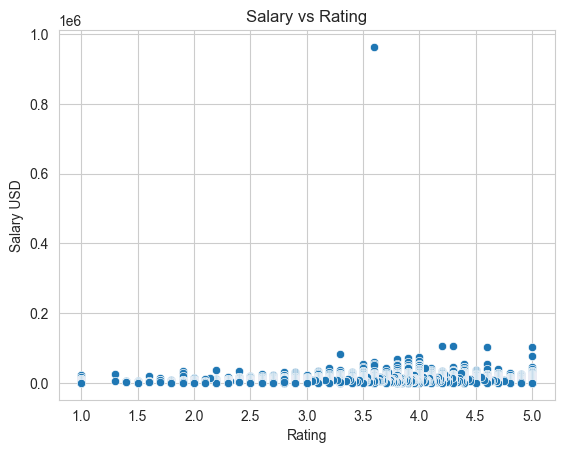

In [12]:
import seaborn as sns

sns.set_style("whitegrid")

# grouping
sps_salary_rating = sps.groupby("Company Name")[['Salary USD', 'Rating']].agg('mean').sort_values(['Rating', 'Salary USD'], ascending=False)
print(sps_salary_rating)

sns.scatterplot(data=sps_salary_rating, y="Salary USD", x="Rating").set(title="Salary vs Rating")

In [13]:
# plotting the anomaly
print(sps.loc[sps['Salary USD'].idxmax(), ['Company Name','Salary USD']])

Company Name    Thapar University
Salary USD                 963170
Name: 18635, dtype: object


*ANSWER*:
Yes, Thapar University has a salary anomaly value, that are ten times the average salary. This led me to suppose that the value had been entered incorrectly and was supposed to be *$96898.9* (divided by 10).

## EXTRA
Let's fix the Thapar University Salart value

In [14]:
# fix the Salary value
sps_fixed = sps.copy()

# change type for division
sps_fixed[['Salary', 'Salary USD']] = sps_fixed[['Salary', 'Salary USD']].astype(float)
# fix the values
sps_fixed.loc[sps_fixed['Company Name']=='Thapar University', ['Salary','Salary USD']] *= 0.1

sps_fixed.loc[sps_fixed['Company Name']=='Thapar University']

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles,Salary USD
18635,3.6,Thapar University,Software Development Engineer (SDE),9000000.0,1,New Delhi,Full Time,SDE,96317.0


[Text(0.5, 1.0, 'Salary vs Rating (Fixed)')]

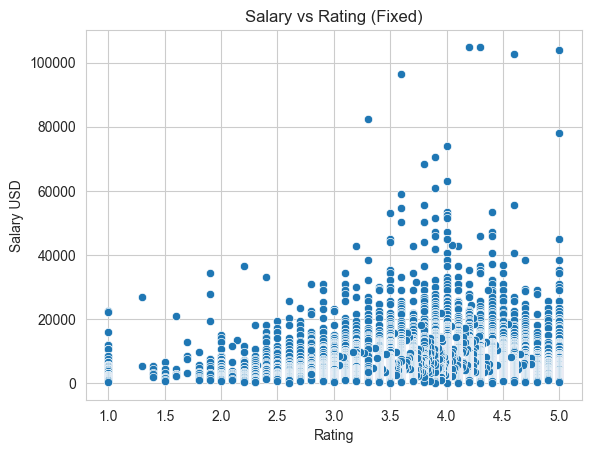

In [15]:
# grouping
sps_fixed_salary_rating = sps_fixed.groupby("Company Name")[['Salary USD', 'Rating']].agg('mean').sort_values(['Rating', 'Salary USD'], ascending=False)

sns.scatterplot(data=sps_fixed_salary_rating, y="Salary USD", x="Rating").set(title="Salary vs Rating (Fixed)")